# Analyze Generated Data

This notebook inspects the simulation dataset produced by `to_export/run_sims.py`.

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_CSV = Path("../results/011626/run1/simulation_results.csv")
assert DATA_CSV.exists(), f"Missing data file: {DATA_CSV}"

df = pd.read_csv(DATA_CSV)
df.shape

(3000, 67)

In [4]:
df["tot_load"] = df["base_load_scale"] * df["load_step_scale"]
df.head()

,sim_id,seed,success,base_load_scale,load_step_scale,load_step_time,base_load_p_total,base_load_q_total,DELTA_PQ_tot,M_agg,...,DELTA_P_PQ_18,DELTA_Q_PQ_18,DELTA_P_PQ_19,DELTA_Q_PQ_19,Delta_P_IBR_1,Delta_P_IBR_2,Delta_P_IBR_3,Delta_P_IBR_4,plotter_csv,tot_load
0,0,42,True,0.996560,0.863327,0.2,58.362566,17.285341,-10.339022,74.691912,...,-0.108962,-0.054481,-0.544811,-0.340507,-1.037385,-0.858845,-0.581166,-1.856771,/home/abdallah/vis-ml/results/to_export/plotte...,0.860358
1,1,42,True,0.633718,1.156059,0.2,37.113074,10.991843,7.507205,64.604856,...,0.079118,0.039559,0.395590,0.247244,0.560961,0.741388,0.413091,0.657454,/home/abdallah/vis-ml/results/to_export/plotte...,0.732616
2,2,42,True,0.982279,0.812716,0.2,57.526185,17.037629,-13.964641,71.468667,...,-0.147172,-0.073586,-0.735862,-0.459914,-1.530214,-1.421469,-1.046223,-1.221510,/home/abdallah/vis-ml/results/to_export/plotte...,0.798313
3,3,42,False,0.970286,1.180506,0.2,56.823826,16.829610,13.294875,56.004186,...,0.140114,0.070057,0.700569,0.437856,0.920650,1.020177,0.781911,-1.498777,/home/abdallah/vis-ml/results/to_export/plotte...,1.145428
4,4,42,True,0.693437,1.099607,0.2,40.610428,12.027660,5.243118,73.148747,...,0.055257,0.027628,0.276284,0.172678,0.391392,0.406003,0.452973,1.119963,/home/abdallah/vis-ml/results/to_export/plotte...,0.762508


In [5]:
df.isna().mean().sort_values(ascending=False).head(20)

sim_id               0.0
seed                 0.0
success              0.0
base_load_scale      0.0
load_step_scale      0.0
load_step_time       0.0
base_load_p_total    0.0
base_load_q_total    0.0
DELTA_PQ_tot         0.0
M_agg                0.0
D_agg                0.0
time_max_dev         0.0
rocof_max_COI        0.0
rocof_min_COI        0.0
devdown_COI          0.0
devup_COI            0.0
M_1                  0.0
D_1                  0.0
M_2                  0.0
D_2                  0.0
dtype: float64

In [6]:
df["success"].value_counts(dropna=False)

success
True     2482
False     518
Name: count, dtype: int64

In [7]:
key_cols = ["base_load_scale", "load_step_scale", "DELTA_PQ_tot", "M_agg", "D_agg"]
df[key_cols].describe()

,base_load_scale,load_step_scale,DELTA_PQ_tot,M_agg,D_agg
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.750891,0.901504,-5.654036,64.790323,14.366207
std,0.261581,0.174918,10.733321,7.130164,4.225180
min,0.300112,0.600119,-36.010859,43.072833,1.264294
25%,0.527832,0.750662,-12.744662,59.940404,11.380970
50%,0.750173,0.902268,-4.926142,64.775485,14.390385
75%,0.980090,1.054021,2.610601,69.717532,17.378087
max,1.199789,1.199986,17.849192,86.493921,26.689519


In [8]:
df[(df["success"]==False) & (df["load_step_scale"]>1)].describe()

,sim_id,seed,base_load_scale,load_step_scale,load_step_time,base_load_p_total,base_load_q_total,DELTA_PQ_tot,M_agg,D_agg,...,DELTA_Q_PQ_17,DELTA_P_PQ_18,DELTA_Q_PQ_18,DELTA_P_PQ_19,DELTA_Q_PQ_19,Delta_P_IBR_1,Delta_P_IBR_2,Delta_P_IBR_3,Delta_P_IBR_4,tot_load
count,518.000000,518.0,518.000000,518.000000,518.0,518.000000,518.000000,518.000000,518.000000,518.000000,...,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000
mean,1524.722008,42.0,0.969570,1.107696,0.2,56.781922,16.817199,7.797768,65.320925,14.516513,...,0.130358,0.082180,0.041090,0.410901,0.256813,0.644075,0.659823,0.531311,-1.859908,1.072296
std,846.104019,0.0,0.139555,0.057064,0.0,8.172878,2.420575,4.267052,7.240044,4.150622,...,0.071334,0.044970,0.022485,0.224851,0.140532,0.309210,0.395892,0.370554,1.517297,0.154262
min,3.000000,42.0,0.655175,1.000867,0.2,38.369648,11.364004,0.077444,46.907539,2.031022,...,0.001295,0.000816,0.000408,0.004081,0.002551,-0.225424,-2.110972,-0.451432,-3.752630,0.777094
25%,799.250000,42.0,0.860955,1.057559,0.2,50.420951,14.933259,4.168930,60.518273,11.553567,...,0.069694,0.043936,0.021968,0.219680,0.137300,0.381707,0.361716,0.321754,-2.739982,0.948959
50%,1574.500000,42.0,0.969810,1.110146,0.2,56.795928,16.821347,7.846871,65.787476,14.219502,...,0.131179,0.082698,0.041349,0.413488,0.258430,0.601680,0.651764,0.535902,-2.276511,1.066944
75%,2218.750000,42.0,1.091929,1.157839,0.2,63.947716,18.939504,10.917333,70.481499,17.634589,...,0.182509,0.115057,0.057529,0.575285,0.359553,0.867410,0.887791,0.774801,-1.854557,1.190380
max,2990.000000,42.0,1.198338,1.199986,0.2,70.179449,20.785167,17.849192,86.493921,25.198491,...,0.298392,0.188111,0.094056,0.940557,0.587848,1.597664,1.777966,1.619136,3.044692,1.431113


In [9]:
df[(df["success"]==True) & (df["load_step_scale"]>1)].describe()

,sim_id,seed,base_load_scale,load_step_scale,load_step_time,base_load_p_total,base_load_q_total,DELTA_PQ_tot,M_agg,D_agg,...,DELTA_Q_PQ_17,DELTA_P_PQ_18,DELTA_Q_PQ_18,DELTA_P_PQ_19,DELTA_Q_PQ_19,Delta_P_IBR_1,Delta_P_IBR_2,Delta_P_IBR_3,Delta_P_IBR_4,tot_load
count,499.000000,499.0,499.000000,499.000000,499.0,499.000000,499.000000,499.000000,499.000000,499.000000,...,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000
mean,1508.959920,42.0,0.512814,1.095054,0.2,30.032427,8.894755,3.620306,65.207426,14.443528,...,0.060522,0.038154,0.019077,0.190771,0.119232,0.278883,0.295280,0.232718,0.462910,0.560506
std,865.412989,0.0,0.128764,0.057835,0.0,7.540935,2.233411,2.332212,6.971934,4.289352,...,0.038988,0.024579,0.012290,0.122895,0.076809,0.209127,0.228991,0.210456,0.504391,0.138127
min,1.000000,42.0,0.301665,1.000119,0.2,17.666680,5.232371,0.006652,45.688165,1.264294,...,0.000111,0.000070,0.000035,0.000351,0.000219,-0.516997,-0.696148,-0.293094,-1.841838,0.305921
25%,762.500000,42.0,0.397616,1.044224,0.2,23.286000,6.896654,1.649444,60.829958,11.453595,...,0.027574,0.017383,0.008692,0.086917,0.054323,0.126057,0.130545,0.104379,0.176211,0.444322
50%,1586.000000,42.0,0.505081,1.089241,0.2,29.579564,8.760630,3.297094,65.396531,14.862583,...,0.055119,0.034748,0.017374,0.173739,0.108587,0.256617,0.272594,0.226041,0.376829,0.562284
75%,2243.500000,42.0,0.607474,1.141117,0.2,35.576134,10.536645,5.286139,69.746778,17.465071,...,0.088370,0.055710,0.027855,0.278551,0.174095,0.409130,0.442617,0.362301,0.650484,0.675369
max,2999.000000,42.0,0.867716,1.199527,0.2,50.816916,15.050533,9.835551,83.795844,26.689519,...,0.164425,0.103656,0.051828,0.518281,0.323926,1.196069,0.949908,0.889574,3.033766,0.869302


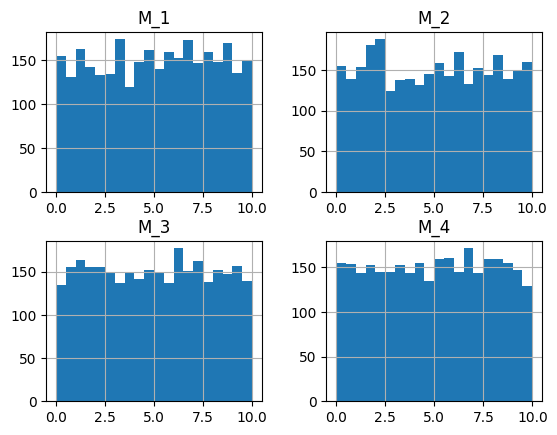

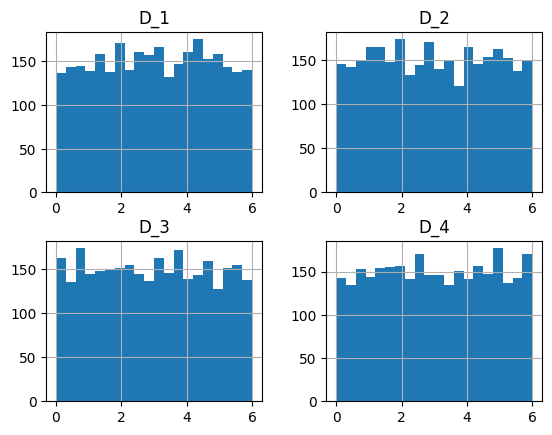

In [10]:
m_cols = [c for c in df.columns if c.startswith("M_") and c[2:].isdigit()]
d_cols = [c for c in df.columns if c.startswith("D_") and c[2:].isdigit()]

df[m_cols].hist(bins=20)
plt.show()
df[d_cols].hist(bins=20)
plt.show()

In [11]:
label_cols = ["rocof_max_COI", "rocof_min_COI", "devdown_COI", "devup_COI"]
df[label_cols].describe()

,rocof_max_COI,rocof_min_COI,devdown_COI,devup_COI
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.167605,-0.057103,0.088829,0.309381
std,0.183534,0.071828,0.164407,0.345171
min,0.000000,-0.421730,0.000000,0.000000
25%,0.008818,-0.071030,0.000000,0.000000
50%,0.106396,-0.027796,0.000000,0.193419
75%,0.276101,-0.011464,0.128312,0.531679
max,0.853434,0.000000,0.981497,1.468877


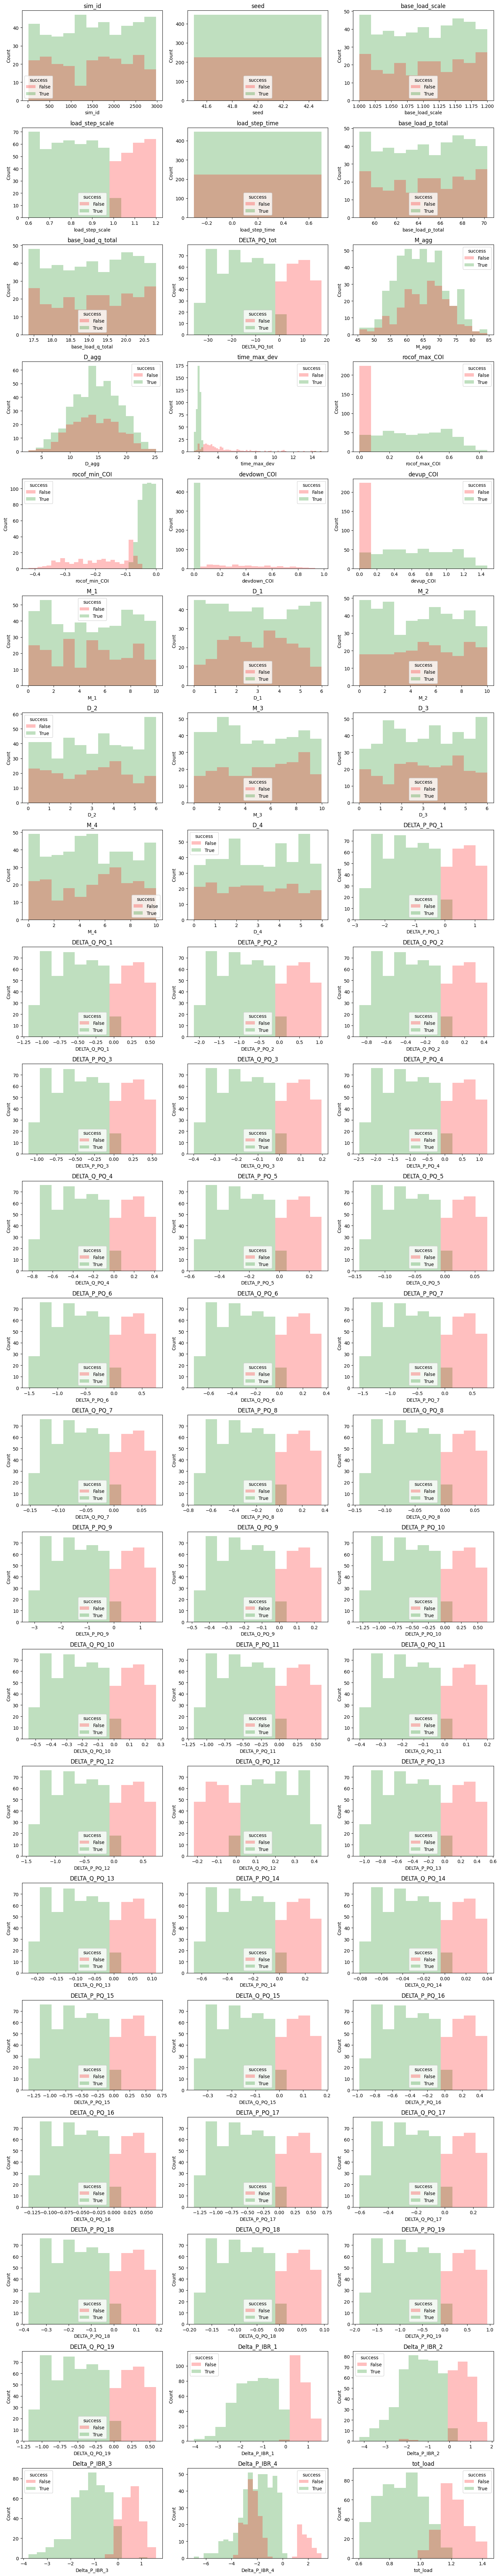

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=np.number).columns
n = len(num_cols)

ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, num_cols):
    sns.histplot(
        data=df[df.base_load_scale>1], x=col, hue="success", # 
        palette={True: "green", False: "red"},
        element="step", common_norm=False,
        edgecolor=None, ax=ax
    )
    ax.set_title(col)

# hide unused axes
for ax in axes[len(num_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


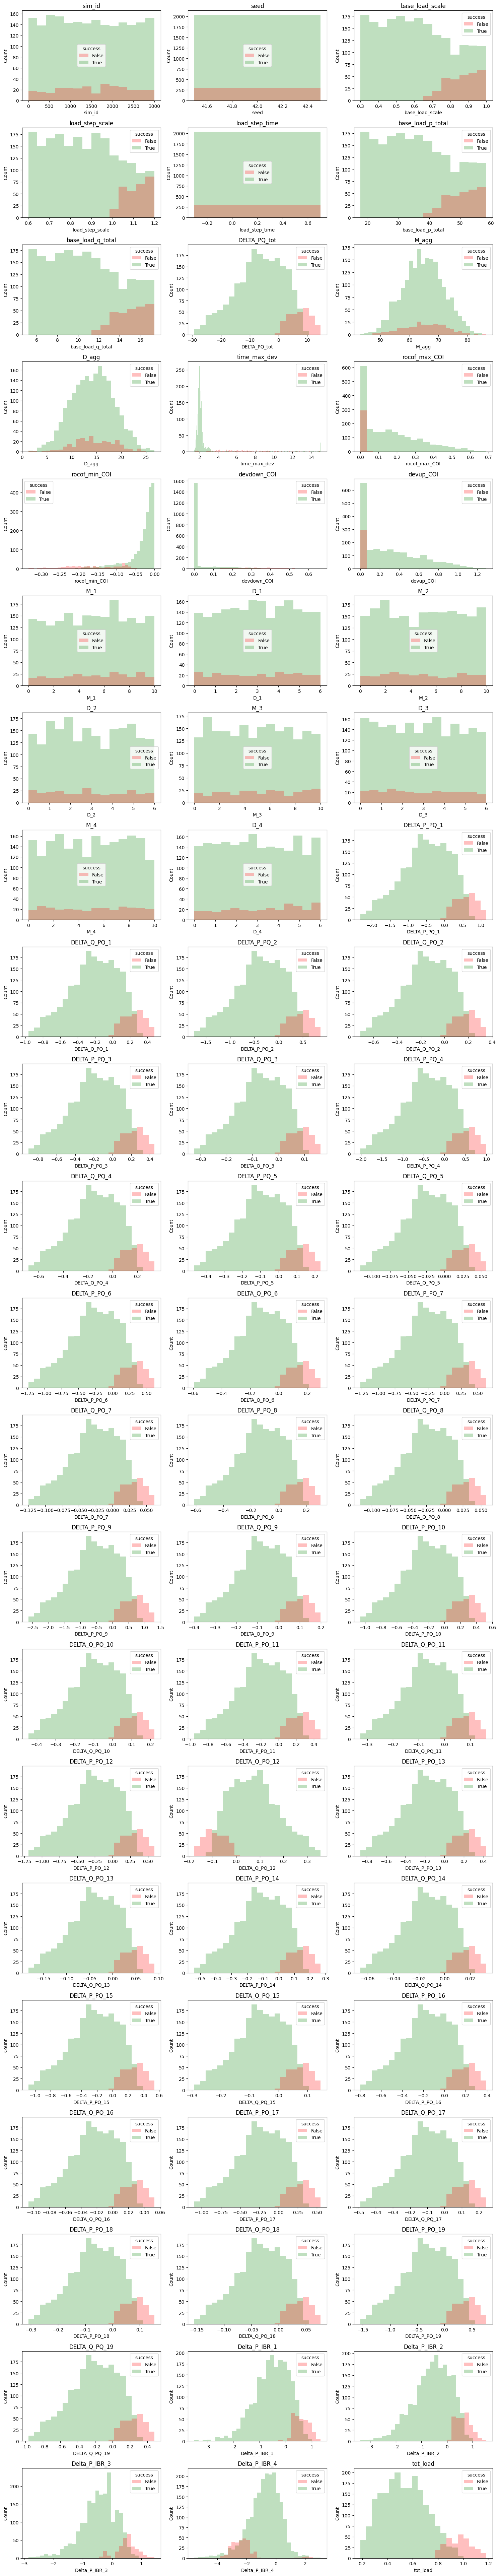

In [ ]:
df[(df["tot_load"] <= 1.2) & (df["success"]==False)]
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=np.number).columns
n = len(num_cols)

ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, num_cols):
    sns.histplot(
        data=df[(df["base_load_scale"] <= 1)], x=col, hue="success",
        palette={True: "green", False: "red"},
        element="step", common_norm=False,
        edgecolor=None, ax=ax
    )
    ax.set_title(col)

# hide unused axes
for ax in axes[len(num_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()